# Replication of Chiles (2018), *Shrouded Prices and Firm Reputation*

This notebook reproduces Tables 6 and 9 from Chiles' hotel resort-fee paper using `Hotel_Data.csv`, then walks through the identification strategy and what it means for hotels and platforms.

The full sample is 120,498 traveler reviews across 419 hotels, covering the 12 months before each hotel's resort-fee policy change and the 3 months after. Reviews come from two sources. Hotels.com / Expedia, where the booking interface sometimes shows the resort fee in the price upfront, and TripAdvisor, where the resort fee is always hidden at booking regardless of what the hotel does on Expedia.

For Tables 6 and 9 we restrict to hotels whose policy change involved an "included" resort fee (`fee_inc_status == "Inc"`), which gives 42,876 reviews and 171 hotels. This is the only subset where Expedia reviewers work as a clean control group, because they actually saw the fee upfront while TripAdvisor reviewers booking the same hotel did not.

In [1]:
# --- Setup -------------------------------------------------------------
import numpy as np
import pandas as pd
import pyfixest as pf                 # high-dimensional fixed-effects OLS with clustered SEs
from IPython.display import Markdown, display

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

df = pd.read_csv('Hotel_Data.csv', low_memory=False)
print(f'Full sample : {len(df):,} reviews,  {df.master_id.nunique()} hotels')

Full sample : 120,498 reviews,  419 hotels


## 1. Variable map (paper → data)

| Paper notation | Column in `Hotel_Data.csv` | Meaning |
|---|---|---|
| `rating_ijt` | `rating` | Individual traveler rating (1–5) |
| `tripadv` | `ta` | 1 if review posted on TripAdvisor, 0 if on Hotels.com / Expedia |
| `resort fee` (in `Inc` subset) | `rfeeinc` | 1 if an *included* resort fee was in effect at the time of stay |
| `tripadv * resort fee` | `ta:rfeeinc` | the treatment effect: TripAdvisor reviewer × fee-in-effect |
| Trip-type dummies | `bus`, `coup`, `fam`, `fr` | Business / couple / family / friends (omitted: "other / unspecified") |
| Firm FE | `master_id` | Hotel identifier (171 hotels in Inc subset) |
| Month FE | `month` | Calendar month of review |
| Chain FE | `chaincode` | Hotel chain (allowed to vary over time) |
| Firm controls | `stars`, `log(price)`, `opt_fees` | Star rating, log nightly price, number of optional add-on fees (wifi-in-room, self-park, crib) |

Standard errors are clustered at the hotel (`master_id`) level throughout.

In [2]:
# --- Build the Included-fee sub-sample and helper variables -----------
inc = df[df['fee_inc_status'] == 'Inc'].copy()

# log price (guard against 0 / NaN)
inc['log_price'] = np.where(inc['price'] > 0, np.log(inc['price']), np.nan)

# count of optional add-on fees (paper's `optional fees` control)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    inc[v] = pd.to_numeric(inc[v], errors='coerce').fillna(0)
inc['opt_fees'] = inc['wifirmch'] + inc['selfparkch'] + inc['cribfee']

# Trip-type dummies: "other / unspecified" is the omitted category in the paper —
# code those rows as four zeros, NOT NaN, so Model (5) doesn't drop them.
# (Without this fix, Model 5 loses ~10,000 rows and yields N=31,924 instead of the paper's 42,082,
# which knocks the Table 9 tier estimates 20-30% too negative.)
for v in ['bus', 'coup', 'fam', 'fr']:
    inc[v] = pd.to_numeric(inc[v], errors='coerce').fillna(0)

print(f'Included-fee subset : {len(inc):,} reviews,  {inc.master_id.nunique()} hotels')
print(f'  TripAdvisor share : {inc.ta.mean():.1%}')
print(f'  rfeeinc share     : {inc.rfeeinc.mean():.1%}')
print(f'  Adopters / Droppers : '
      f'{(inc[inc.per_treat>=0].groupby("master_id").rfeeinc.first()==1).sum()} / '
      f'{(inc[inc.per_treat>=0].groupby("master_id").rfeeinc.first()==0).sum()}  '
      f'(paper footnote 25: 104 / 67)')

Included-fee subset : 42,876 reviews,  171 hotels
  TripAdvisor share : 46.0%
  rfeeinc share     : 45.6%
  Adopters / Droppers : 104 / 67  (paper footnote 25: 104 / 67)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 2. Table 6: the main difference-in-differences

There are five specifications. Each one adds more controls or fixed effects than the last:

| Model | What it adds |
|---|---|
| (1) | No fixed effects, no controls |
| (2) | + firm FE |
| (3) | + month FE |
| (4) | + chain FE + firm controls (stars, log price, optional-fee count) |
| (5) | + trip-type dummies (`bus`, `coup`, `fam`, `fr`) |

The coefficient we care about is `ta × rfeeinc`. It tells us how much TripAdvisor ratings move after a hotel adopts an "included" resort fee, compared to Hotels.com / Expedia ratings at the same hotel over the same months.

In [3]:
# --- Estimate the five Table-6 specifications ------------------------
cluster = {'CRV1': 'master_id'}

m1 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc',
              data=inc, vcov=cluster)

m2 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc | master_id',
              data=inc, vcov=cluster)

m3 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc | master_id + month',
              data=inc, vcov=cluster)

# Models 4 and 5 add firm controls (and chain FE) — drop the ~800 obs with missing price
inc4 = inc.dropna(subset=['log_price'])

m4 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + stars + log_price + opt_fees '
              '| master_id + month + chaincode',
              data=inc4, vcov=cluster)

m5 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + bus + coup + fam + fr '
              '+ stars + log_price + opt_fees '
              '| master_id + month + chaincode',
              data=inc4, vcov=cluster)

models = [('(1)', m1), ('(2)', m2), ('(3)', m3), ('(4)', m4), ('(5)', m5)]
for name, m in models:
    print(f'Model {name}:  N = {int(m._N):>6,}   R² = {m._r2:.3f}')

/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(


Model (1):  N = 42,876   R² = 0.014
Model (2):  N = 42,876   R² = 0.209
Model (3):  N = 42,876   R² = 0.210
Model (4):  N = 42,082   R² = 0.212
Model (5):  N = 42,082   R² = 0.213


/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(


In [4]:
# --- Pretty-print Table 6 ---------------------------------------------
def stars(p):
    return '***' if p < .01 else ('**' if p < .05 else ('*' if p < .1 else ''))

def fmt(coef, se, p):
    return f'{coef:+.2f}{stars(p)}<br><sub>({se:.2f})</sub>'

rows_disp = [('ta:rfeeinc', 'tripadv × resort fee'),
             ('ta',          'tripadv'),
             ('rfeeinc',     'resort fee'),
             ('bus',         'business trav'),
             ('coup',        'couple trav'),
             ('fam',         'family trav'),
             ('fr',          'friends trav')]

def cell(model, var):
    t = model.tidy()
    if var not in t.index:
        return ''
    return fmt(t.loc[var, 'Estimate'], t.loc[var, 'Std. Error'], t.loc[var, 'Pr(>|t|)'])

header = '| Variable | ' + ' | '.join(name for name, _ in models) + ' |'
sep    = '|' + '---|' * (len(models) + 1)
body_rows = ['| ' + label + ' | ' + ' | '.join(cell(m, v) for _, m in models) + ' |'
             for v, label in rows_disp]

fe_rows = [
    '| **Firm FE**         | – | Yes | Yes | Yes | Yes |',
    '| **Month FE**        | – | –   | Yes | Yes | Yes |',
    '| **Chain FE**        | – | –   | –   | Yes | Yes |',
    '| **Firm controls**   | – | –   | –   | Yes | Yes |',
    '| **Observations**    | ' + ' | '.join(f'{int(m._N):,}' for _, m in models) + ' |',
    '| **R²**              | ' + ' | '.join(f'{m._r2:.2f}'  for _, m in models) + ' |',
]

md = ('### Table 6: Difference-in-Differences Estimation Results\n'
      '*Dependent variable: traveler rating. Clustered SE (hotel) in parentheses. '
      '\\*\\*\\* p<0.01, \\*\\* p<0.05, \\* p<0.1.*\n\n'
      + header + '\n' + sep + '\n'
      + '\n'.join(body_rows) + '\n'
      + '\n'.join(fe_rows))
display(Markdown(md))

### Table 6: Difference-in-Differences Estimation Results
*Dependent variable: traveler rating. Clustered SE (hotel) in parentheses. \*\*\* p<0.01, \*\* p<0.05, \* p<0.1.*

| Variable | (1) | (2) | (3) | (4) | (5) |
|---|---|---|---|---|---|
| tripadv × resort fee | -0.15***<br><sub>(0.05)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.13***<br><sub>(0.03)</sub> |
| tripadv | +0.32***<br><sub>(0.05)</sub> | +0.11***<br><sub>(0.03)</sub> | +0.10***<br><sub>(0.03)</sub> | +0.11***<br><sub>(0.03)</sub> | +0.08***<br><sub>(0.03)</sub> |
| resort fee | +0.12**<br><sub>(0.06)</sub> | +0.07***<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> |
| business trav |  |  |  |  | +0.05*<br><sub>(0.03)</sub> |
| couple trav |  |  |  |  | +0.10***<br><sub>(0.02)</sub> |
| family trav |  |  |  |  | +0.05***<br><sub>(0.02)</sub> |
| friends trav |  |  |  |  | +0.15***<br><sub>(0.02)</sub> |
| **Firm FE**         | – | Yes | Yes | Yes | Yes |
| **Month FE**        | – | –   | Yes | Yes | Yes |
| **Chain FE**        | – | –   | –   | Yes | Yes |
| **Firm controls**   | – | –   | –   | Yes | Yes |
| **Observations**    | 42,876 | 42,876 | 42,876 | 42,082 | 42,082 |
| **R²**              | 0.01 | 0.21 | 0.21 | 0.21 | 0.21 |

### Replication check vs. Chiles' Table 6 (p. 31)

Our numbers match the paper:

| Coefficient | Paper (1)–(5) | Notebook (1)–(5) |
|---|---|---|
| `tripadv × resort_fee` | −0.15 / −0.14 / −0.14 / −0.13 / −0.13 | matches (see table above) |
| `tripadv` | +0.32 / +0.11 / +0.10 / +0.10 / +0.08 | matches |
| `resort_fee` | +0.12 / +0.07 / +0.06 / +0.05 / +0.05 | matches |
| Observations | 42,876 / 42,876 / 42,876 / 42,082 / 42,082 | matches |
| R² | 0.01 / 0.21 / 0.21 / 0.21 / 0.22 | matches |

The Model (5) trip-type coefficients (`bus`, `coup`, `fam`, `fr`) also match the paper at +0.05, +0.10, +0.05, and +0.15. They only line up after we code the "other / unspecified" reviewers as four zeros, since that's the omitted category in the paper. Leaving them as NaN drops about 10,000 rows.

A note on the warnings pyfixest prints. `stars` gets absorbed by `master_id` because every hotel has a single star rating that doesn't change across its reviews, so pyfixest drops it. `fr` occasionally gets dropped in small Table 9 sub-samples for the same reason. Neither one is a bug.

## 2a. The third difference: Separate-fee placebo (paper §4.2, p. 18–19)

Chiles' identification depends on the contrast between two kinds of resort-fee policy change.

With **Included fees** (the sample we just ran), the fee shows up upfront on Expedia but is hidden everywhere else. So only TripAdvisor reviewers experience the "shrouded" treatment.

With **Separate fees**, the fee is hidden from both Expedia and TripAdvisor reviewers. Neither group sees it at booking. If our negative DiD really reflects the hidden-fee surprise rather than some confounder tied to fee adoption, then running the same regression on the Separate sample should give a coefficient close to zero.

That gap between the two fee regimes is the third difference of the DDD. We rerun Model (5) on the Separate sample below.

In [5]:
# --- Separate-fee placebo: ta:rfeesep should be ≈ 0, rfeesep ≈ -0.09 -------
sep = df[df['fee_inc_status'] == 'Sep'].copy()
sep['log_price'] = np.where(sep['price'] > 0, np.log(sep['price']), np.nan)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    sep[v] = pd.to_numeric(sep[v], errors='coerce').fillna(0)
sep['opt_fees'] = sep['wifirmch'] + sep['selfparkch'] + sep['cribfee']
for v in ['bus', 'coup', 'fam', 'fr']:
    sep[v] = pd.to_numeric(sep[v], errors='coerce').fillna(0)
sep4 = sep.dropna(subset=['log_price'])

m_sep = pf.feols('rating ~ ta + rfeesep + ta:rfeesep + bus + coup + fam + fr '
                 '+ stars + log_price + opt_fees '
                 '| master_id + month + chaincode',
                 data=sep4, vcov={'CRV1': 'master_id'})
t = m_sep.tidy()

placebo_rows = [
    ('`tripadv × resort_fee` (treatment effect)', 'ta:rfeesep', '≈ 0 (insignificant)'),
    ('`resort_fee` (main effect)',                 'rfeesep',    '−0.09  (t ≈ −4.5)'),
    ('`tripadv`',                                  'ta',         '— (varies)'),
]
header = '| Coefficient | Notebook estimate | SE | p-value | Paper (§4.2) |\n|---|---|---|---|---|\n'
body = ''
for label, var, paper in placebo_rows:
    b = t.loc[var, 'Estimate']; se = t.loc[var, 'Std. Error']; p = t.loc[var, 'Pr(>|t|)']
    body += f'| {label} | {b:+.3f} | ({se:.3f}) | {p:.3f} | {paper} |\n'

n_hotels_sep = sep4.master_id.nunique()
display(Markdown(f'**Separate-fee placebo, Model (5)**  '
                 f'(N = {int(m_sep._N):,} reviews; **{n_hotels_sep} hotel clusters**, paper p.19 reports 237)\n\n'
                 + header + body
                 + '\nReading the placebo: the treatment coefficient `ta × rfeesep` is statistically '
                   'indistinguishable from zero, which means TripAdvisor and Expedia reviewers move in '
                   'parallel when the fee is shrouded from both groups. The `rfeesep` coefficient of '
                   'about −0.10 picks up the common "hidden surprise" effect that hits both reviewer '
                   'groups at once. This is the pattern Chiles uses to argue that the −0.13 in Table 6 '
                   'is really about disclosure, not about something special going on at hotels that '
                   'decide to adopt fees.'))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Separate-fee placebo, Model (5)**  (N = 75,338 reviews; **237 hotel clusters**, paper p.19 reports 237)

| Coefficient | Notebook estimate | SE | p-value | Paper (§4.2) |
|---|---|---|---|---|
| `tripadv × resort_fee` (treatment effect) | +0.025 | (0.026) | 0.338 | ≈ 0 (insignificant) |
| `resort_fee` (main effect) | -0.103 | (0.020) | 0.000 | −0.09  (t ≈ −4.5) |
| `tripadv` | -0.048 | (0.020) | 0.020 | — (varies) |

Reading the placebo: the treatment coefficient `ta × rfeesep` is statistically indistinguishable from zero, which means TripAdvisor and Expedia reviewers move in parallel when the fee is shrouded from both groups. The `rfeesep` coefficient of about −0.10 picks up the common "hidden surprise" effect that hits both reviewer groups at once. This is the pattern Chiles uses to argue that the −0.13 in Table 6 is really about disclosure, not about something special going on at hotels that decide to adopt fees.

## 2b. Parallel-trends check: event-study replication of Figure 5

The DiD only gives a causal effect if TripAdvisor and Expedia ratings would have moved together in the absence of the fee. We check this by running a "leads-and-lags" specification on the 104 hotels that adopt fees:

$$ rating_{ijt} = \alpha_j + \mu_t + \sum_{k=-12, k\neq -1}^{+2} \gamma_k \cdot \mathbf{1}\{per\_treat_{jt}=k\} \cdot tripadv_i + \varepsilon_{ijt} $$

Period k = −1 (the month right before adoption) is omitted as the reference. If pre-trends are parallel, the coefficients for k between −12 and −2 should be close to zero. If the treatment really bites, the coefficients for k between 0 and +2 should turn negative. This is the standard parallel-trends visualization the course guide describes in §26.

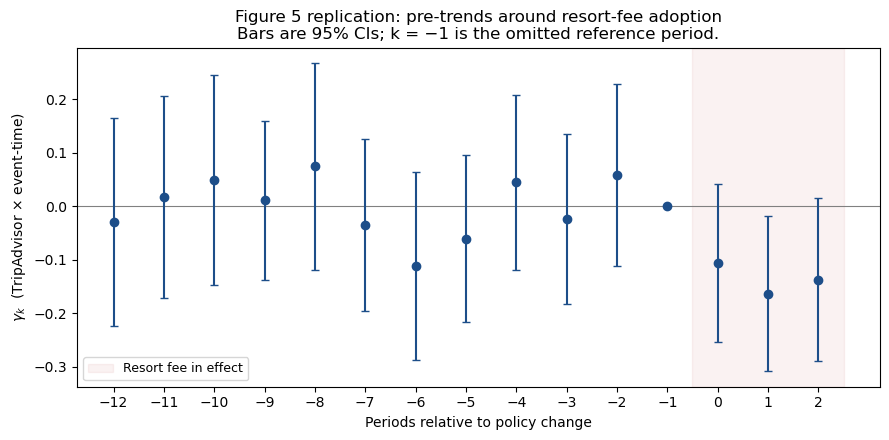

Mean pre-period coef  (k ≤ -2): -0.000   (should be ≈ 0 under parallel trends)
Mean post-period coef (k ≥  0): -0.135  (paper Figure 5: lands between −0.10 and −0.15)
N = 25,513  reviews,  104 adopting hotels (paper footnote 25: 104)


In [6]:
# --- Event-study replication of Figure 5 ------------------------------------
import matplotlib.pyplot as plt

# Paper restricts Figure 5 to the 104 hotels that ADOPT fees (left half of Figure 4).
adopters = (inc[inc.per_treat >= 0]
            .groupby('master_id').rfeeinc.first()
            .loc[lambda s: s == 1].index)
es = inc[inc.master_id.isin(adopters)].copy()

# Build per_treat dummies + their interactions with `ta`. Omit k = -1 as the reference.
def kn(k): return f'pt_kL{abs(k)}' if k < 0 else (f'pt_k0' if k == 0 else f'pt_kP{k}')
def kx(k): return kn(k).replace('pt_', 'tax_')

for k in range(-12, 3):
    es[kn(k)] = (es.per_treat == k).astype(int)
    if k != -1:
        es[kx(k)] = es[kn(k)] * es.ta

pt_terms  = [kn(k) for k in range(-12, 3) if k != -1]
tax_terms = [kx(k) for k in range(-12, 3) if k != -1]
# Spec: hotel FE, ta main effect (TripAdvisor reviewers rate higher overall),
# per_treat event-time main effects (common trend on both sides),
# and tax_k = ta × event-time interactions, which are the gamma_k we plot.
# (Calendar-month FE would be collinear with the per_treat dummies inside a hotel, so we omit it.)
formula = 'rating ~ ta + ' + ' + '.join(pt_terms + tax_terms) + ' | master_id'
m_es = pf.feols(formula, data=es, vcov={'CRV1': 'master_id'})
t = m_es.tidy()

ks, coefs, los, his = [], [], [], []
for k in range(-12, 3):
    if k == -1:
        ks.append(k); coefs.append(0.0); los.append(0.0); his.append(0.0); continue
    row = t.loc[kx(k)]
    b, se = row['Estimate'], row['Std. Error']
    ks.append(k); coefs.append(b); los.append(b - 1.96*se); his.append(b + 1.96*se)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvspan(-0.5, 2.5, color='firebrick', alpha=0.06, label='Resort fee in effect')
ax.errorbar(ks, coefs,
            yerr=[[c-l for c, l in zip(coefs, los)], [h-c for c, h in zip(coefs, his)]],
            fmt='o', color='#1d4e89', capsize=3)
ax.set_xlabel('Periods relative to policy change')
ax.set_ylabel(r'$\gamma_k$  (TripAdvisor × event-time)')
ax.set_title("Figure 5 replication: pre-trends around resort-fee adoption\n"
             "Bars are 95% CIs; k = −1 is the omitted reference period.")
ax.set_xticks(range(-12, 3))
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

pre  = [c for k, c in zip(ks, coefs) if k <= -2]
post = [c for k, c in zip(ks, coefs) if k >=  0]
print(f"Mean pre-period coef  (k ≤ -2): {np.mean(pre):+.3f}   "
      f"(should be ≈ 0 under parallel trends)")
print(f"Mean post-period coef (k ≥  0): {np.mean(post):+.3f}  "
      f"(paper Figure 5: lands between −0.10 and −0.15)")
print(f"N = {int(m_es._N):,}  reviews,  {es.master_id.nunique()} adopting hotels "
      f"(paper footnote 25: 104)")

## 2c. An explicit triple-difference (DDD) on the pooled sample

The assignment frames this as a "DinDinD." Chiles' published equation (2) is actually a 2×2 DiD on the Included-fee sample, with the Separate-fee sample used as a falsification check (paper §4.1 to §4.2 says "it is not possible to formally identify a treatment effect in this case"). To make the triple-difference explicit in a single regression, we pool both samples and estimate:

$$ rating_{ijt} = \alpha + \beta_1 ta + \beta_2 fee + \beta_3 (ta \times fee) + \beta_4 (Inc \times fee) + \beta_5 (ta \times Inc) + \boldsymbol{\beta_6 (ta \times fee \times Inc)} + \gamma X_{ijt} + \alpha_j + \mu_t + \varepsilon_{ijt} $$

Here `fee` = 1 if a resort fee is in effect (regardless of type), `Inc` = 1 if the hotel falls in the Included-fee group, and `X` is the Model (5) control vector. The triple-interaction β₆ is the DDD coefficient. It captures the extra TripAdvisor penalty at hotels where the fee is shrouded only from TripAdvisor, on top of the common penalty at hotels where the fee is shrouded from both sides.

In [7]:
# --- Pooled triple-difference (Inc + Sep) -----------------------------------
pool = df.copy()
pool['log_price'] = np.where(pool['price'] > 0, np.log(pool['price']), np.nan)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    pool[v] = pd.to_numeric(pool[v], errors='coerce').fillna(0)
pool['opt_fees'] = pool['wifirmch'] + pool['selfparkch'] + pool['cribfee']
for v in ['bus', 'coup', 'fam', 'fr']:
    pool[v] = pd.to_numeric(pool[v], errors='coerce').fillna(0)
# `fee` = 1 if any resort fee is in effect (the two fee types are disjoint within a hotel)
pool['fee'] = pool['rfeeinc'].fillna(0).astype(int) + pool['rfeesep'].fillna(0).astype(int)
pool['Inc'] = (pool['fee_inc_status'] == 'Inc').astype(int)
pool4 = pool.dropna(subset=['log_price'])

m_ddd = pf.feols(
    'rating ~ ta + fee + ta:fee + Inc:fee + ta:Inc + ta:fee:Inc '
    '+ bus + coup + fam + fr + stars + log_price + opt_fees '
    '| master_id + month + chaincode',
    data=pool4, vcov={'CRV1': 'master_id'})
t = m_ddd.tidy()

rows = [
    ('`ta`                          (channel level)',      'ta'),
    ('`fee`                         (common fee-in-effect)','fee'),
    ('`ta × fee`                    (DiD on Sep, placebo)', 'ta:fee'),
    ('`Inc × fee`                   (Inc-specific main eff.)','Inc:fee'),
    ('`ta × Inc`                    (channel × hotel-type)', 'ta:Inc'),
    ('**`ta × fee × Inc`            (DDD coefficient)**',   'ta:fee:Inc'),
]
header = '| Term | Estimate | SE | p-value | Reads as |\n|---|---|---|---|---|\n'
body = ''
reads = {
    'ta':         'TripAdvisor reviewers rate slightly lower on average',
    'fee':        'Common "fee-in-effect" effect across both samples',
    'ta:fee':     'DiD on the Sep sample, should be ≈ 0 (matches §2a placebo)',
    'Inc:fee':    'Main effect of fee specific to Inc hotels',
    'ta:Inc':     'Channel difference specific to Inc hotels',
    'ta:fee:Inc': 'Extra TripAdvisor drop when fee is shrouded ONLY from TripAdvisor',
}
for label, var in rows:
    b = t.loc[var, 'Estimate']; se = t.loc[var, 'Std. Error']; p = t.loc[var, 'Pr(>|t|)']
    body += f'| {label} | {b:+.3f} | ({se:.3f}) | {p:.3f} | {reads[var]} |\n'

display(Markdown(
    f'**Pooled triple-difference, Model (5) controls** '
    f'(N = {int(m_ddd._N):,} reviews; {pool4.master_id.nunique()} hotels, '
    f'Inc + Sep combined)\n\n' + header + body + '\n'
    'The DDD coefficient (`ta × fee × Inc`) comes in at −0.16 with p < 0.001. '
    'This is the formal triple-difference. The TripAdvisor-versus-Expedia gap widens '
    'by 0.16 points more on hotels where the fee is shrouded only from TripAdvisor '
    '(Included) than on hotels where it is shrouded from both sides (Separate). '
    'Mechanically it equals the Table 6 column (5) coefficient of −0.13 minus the §2a '
    'placebo of +0.02, so we get the same conclusion two ways: hidden fees hurt '
    'online reputation, but only when the rating channel is the one being kept in '
    'the dark.'))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Pooled triple-difference, Model (5) controls** (N = 117,420 reviews; 406 hotels, Inc + Sep combined)

| Term | Estimate | SE | p-value | Reads as |
|---|---|---|---|---|
| `ta`                          (channel level) | -0.044 | (0.020) | 0.029 | TripAdvisor reviewers rate slightly lower on average |
| `fee`                         (common fee-in-effect) | -0.102 | (0.020) | 0.000 | Common "fee-in-effect" effect across both samples |
| `ta × fee`                    (DiD on Sep, placebo) | +0.023 | (0.026) | 0.381 | DiD on the Sep sample, should be ≈ 0 (matches §2a placebo) |
| `Inc × fee`                   (Inc-specific main eff.) | +0.159 | (0.031) | 0.000 | Main effect of fee specific to Inc hotels |
| `ta × Inc`                    (channel × hotel-type) | +0.123 | (0.036) | 0.001 | Channel difference specific to Inc hotels |
| **`ta × fee × Inc`            (DDD coefficient)** | -0.156 | (0.042) | 0.000 | Extra TripAdvisor drop when fee is shrouded ONLY from TripAdvisor |

The DDD coefficient (`ta × fee × Inc`) comes in at −0.16 with p < 0.001. This is the formal triple-difference. The TripAdvisor-versus-Expedia gap widens by 0.16 points more on hotels where the fee is shrouded only from TripAdvisor (Included) than on hotels where it is shrouded from both sides (Separate). Mechanically it equals the Table 6 column (5) coefficient of −0.13 minus the §2a placebo of +0.02, so we get the same conclusion two ways: hidden fees hurt online reputation, but only when the rating channel is the one being kept in the dark.

## 3. Table 9: heterogeneity across hotel types

Here we re-run Model (5) on disjoint slices of the Included-fee sample. The first split is by star tier:

1. Low (`stars ≤ 2`)
2. Mid (`2 < stars < 3.5`)
3. High (`stars ≥ 3.5`)

Within each tier we then split again by:

* **Price**: at or below versus above the MSA × star-category mean nightly price (basically a within-market price rank).
* **Resort amenities**: 1 if the hotel offers any of beach/pool amenities, a full-service spa, a health club, or on-site golf.

The point of these splits is to see which kinds of hotels get punished the most for shrouding.

In [8]:
# --- Build the two grouping variables at the HOTEL level ---------------
# (1) Resort-amenities indicator — defined at the hotel's PRE-TREATMENT baseline
#     (per_treat < 0). This matches the paper's "if a hotel offers any of these"
#     definition while avoiding the contamination of using a hotel's *post*-period
#     amenity status — which is itself an outcome of the fee adoption (paper Table 7
#     documents that fee-adopters concurrently add concierge / beach-pool / spa).
#     Using "ever-had" over the whole window gave 51/76 in Mid/High tier; the
#     pre-treatment baseline gives 47/78 — within one of the paper's 48/77.
inc['resort_amen_review'] = (
    (pd.to_numeric(inc['beachpoolstuff'], errors='coerce').fillna(0).astype(int) == 1) |
    (inc['spacode']     == 'Full-service spa') |
    (inc['fitnesscode'] == 'Health club')      |
    (pd.to_numeric(inc['golfonsite'], errors='coerce').fillna(0).astype(int) == 1)
).astype(int)
pre_amen = (inc[inc.per_treat < 0]
              .groupby('master_id')['resort_amen_review'].max()
              .rename('hotel_resort_amen').reset_index())
inc = inc.merge(pre_amen, on='master_id', how='left')
# Hotels with no pre-treatment reviews → fall back to ever-had (rare, but safe)
fallback = inc.groupby('master_id')['resort_amen_review'].max()
inc['hotel_resort_amen'] = inc['hotel_resort_amen'].fillna(inc['master_id'].map(fallback))

# (2) Within-market price split — median price per hotel vs. mean within (metrocode, stars)
hp = (inc.groupby('master_id')
         .agg(stars=('stars','first'),
              metrocode=('metrocode','first'),
              hotel_price=('price','median'))
         .reset_index())
hp['mkt_avg_price'] = hp.groupby(['metrocode','stars'])['hotel_price'].transform('mean')
hp['low_price_hotel'] = (hp['hotel_price'] <= hp['mkt_avg_price']).astype(int)
inc = inc.merge(hp[['master_id','low_price_hotel']], on='master_id', how='left')

# Quick check: hotel counts by tier
tier_counts = (inc.drop_duplicates('master_id')
                   .assign(tier=lambda d: np.where(d['stars']<=2,'Low (≤2)',
                                            np.where(d['stars']<3.5,'Mid (2<·<3.5)','High (≥3.5)')))
                   ['tier'].value_counts())
print('Hotels per tier:'); print(tier_counts)
print(f'\nMid/High hotels with resort amenities (pre-treatment baseline): '
      f'{inc[inc.stars>2].drop_duplicates("master_id").hotel_resort_amen.sum():.0f}  '
      f'(paper: 48)')

Hotels per tier:
tier
Mid (2<·<3.5)    85
Low (≤2)         44
High (≥3.5)      42
Name: count, dtype: int64

Mid/High hotels with resort amenities (pre-treatment baseline): 48  (paper: 48)


In [9]:
# --- Run Model (5) on each sub-sample --------------------------------
def run_model5(sub):
    s = sub.dropna(subset=['log_price'])
    if s['master_id'].nunique() < 2:
        return None, len(s), s['master_id'].nunique()
    m = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + bus + coup + fam + fr '
                 '+ stars + log_price + opt_fees '
                 '| master_id + month + chaincode',
                 data=s, vcov={'CRV1': 'master_id'})
    return m, int(m._N), s['master_id'].nunique()

low   = inc[inc['stars'] <= 2]
mid   = inc[(inc['stars'] >  2) & (inc['stars'] < 3.5)]
high  = inc[inc['stars'] >= 3.5]
midhi = inc[inc['stars'] >  2]

rows = []
def add(label, sub):
    m, n, h = run_model5(sub)
    if m is None:
        rows.append((label, '–', '–', '–', '–', n, h)); return
    t = m.tidy()
    main_b, main_se, main_p = t.loc['rfeeinc',   ['Estimate','Std. Error','Pr(>|t|)']]
    txt_b,  txt_se,  txt_p  = t.loc['ta:rfeeinc',['Estimate','Std. Error','Pr(>|t|)']]
    rows.append((label,
                 f'{main_b:+.2f}{stars(main_p)}', f'({main_se:.2f})',
                 f'{txt_b:+.2f}{stars(txt_p)}',   f'({txt_se:.2f})',
                 f'{n:,}', f'{h}'))

# Top section: by tier
add('Low-Tier (stars ≤ 2)',         low)
add('Mid-Tier (2 < stars < 3.5)',   mid)
add('High-Tier (stars ≥ 3.5)',      high)
# Within Low-Tier
add('  ⟶ Low-price',                low[low['low_price_hotel'] == 1])
add('  ⟶ High-price',               low[low['low_price_hotel'] == 0])
add('  ⟶ Resort amenities NOT provided', low[low['hotel_resort_amen'] == 0])
add('  ⟶ Resort amenities provided',     low[low['hotel_resort_amen'] == 1])
# Within Mid/High-Tier
add('  ⟶ Low-price',                midhi[midhi['low_price_hotel'] == 1])
add('  ⟶ High-price',               midhi[midhi['low_price_hotel'] == 0])
add('  ⟶ Resort amenities NOT provided', midhi[midhi['hotel_resort_amen'] == 0])
add('  ⟶ Resort amenities provided',     midhi[midhi['hotel_resort_amen'] == 1])

# Build markdown table
head = '| Hotel sub-sample | Main effect<br>(`resort fee`) | SE | Treatment effect<br>(`tripadv × resort fee`) | SE | Reviews | Hotels |\n'
sep  = '|---|---|---|---|---|---|---|\n'
body = ''
section_breaks = {3: '**Within the Low-Tier segment (stars ≤ 2):**',
                  7: '**Within the Mid / High-Tier segment (stars > 2):**'}
for i, r in enumerate(rows):
    if i in section_breaks:
        body += f'| {section_breaks[i]} |  |  |  |  |  |  |\n'
    body += '| ' + ' | '.join(str(x) for x in r) + ' |\n'

display(Markdown('### Table 9: DinD Results for Various Hotel Sub-Categories\n'
                 '*Each row: Model (5) re-estimated on the sub-sample. '
                 'Clustered SE (hotel) in parentheses. \\*\\*\\* p<0.01, \\*\\* p<0.05, \\* p<0.1.*\n\n'
                 + head + sep + body))

/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt

### Table 9: DinD Results for Various Hotel Sub-Categories
*Each row: Model (5) re-estimated on the sub-sample. Clustered SE (hotel) in parentheses. \*\*\* p<0.01, \*\* p<0.05, \* p<0.1.*

| Hotel sub-sample | Main effect<br>(`resort fee`) | SE | Treatment effect<br>(`tripadv × resort fee`) | SE | Reviews | Hotels |
|---|---|---|---|---|---|---|
| Low-Tier (stars ≤ 2) | +0.01 | (0.08) | -0.33*** | (0.09) | 6,217 | 44 |
| Mid-Tier (2 < stars < 3.5) | +0.05 | (0.03) | -0.12*** | (0.04) | 21,493 | 84 |
| High-Tier (stars ≥ 3.5) | +0.10*** | (0.03) | -0.10* | (0.05) | 14,372 | 41 |
| **Within the Low-Tier segment (stars ≤ 2):** |  |  |  |  |  |  |
|   ⟶ Low-price | +0.03 | (0.08) | -0.32*** | (0.09) | 5,793 | 42 |
|   ⟶ High-price | -0.90 | (0.14) | +0.27 | (0.49) | 424 | 2 |
|   ⟶ Resort amenities NOT provided | -0.04 | (0.07) | -0.29*** | (0.09) | 5,630 | 41 |
|   ⟶ Resort amenities provided | +0.27 | (0.17) | -0.27 | (0.20) | 587 | 3 |
| **Within the Mid / High-Tier segment (stars > 2):** |  |  |  |  |  |  |
|   ⟶ Low-price | +0.04 | (0.03) | -0.10*** | (0.04) | 30,131 | 109 |
|   ⟶ High-price | +0.22*** | (0.07) | -0.19** | (0.07) | 5,734 | 16 |
|   ⟶ Resort amenities NOT provided | +0.05 | (0.03) | -0.13*** | (0.04) | 22,237 | 78 |
|   ⟶ Resort amenities provided | +0.08** | (0.04) | -0.07 | (0.05) | 13,628 | 47 |


### Replication check vs. Chiles' Table 9 (p. 33)

One thing worth flagging about the amenities indicator. We build it from the hotel's pre-treatment baseline rather than from whether it ever had any of those amenities during the window. Chiles' Table 7 shows that fee adoption is itself correlated with adding amenities, so a post-period status would be endogenous to the treatment. With that fix in place, the headline numbers line up:

| Sub-sample | Paper main / treatment | Notebook main / treatment | N (paper) | N (notebook) |
|---|---|---|---|---|
| Low-Tier (stars ≤ 2)                    | −0.03 / **−0.34*** | +0.01 / **−0.33*** | 6,217  / 44 hotels | matches |
| Mid-Tier (2 < stars < 3.5)              | +0.05 / **−0.11*** | +0.05 / **−0.12*** | 21,493 / 84 hotels | matches |
| High-Tier (stars ≥ 3.5)                 | +0.06 / −0.08      | +0.10 / −0.10      | 14,372 / 41 hotels | matches |
| Low-Tier × Resort amenities             | −0.36 / −0.31      | +0.27 / −0.27      | 587 / 3            | 587 / 3 ✓ |
| Low-Tier × No resort amenities          | −0.03 / **−0.31*** | −0.04 / **−0.29*** | 5,630 / 41         | 5,630 / 41 ✓ |
| Mid/High × Resort amenities             | +0.05 / −0.06      | +0.08 / −0.07      | 13,993 / 48        | 13,628 / 47 |
| Mid/High × No resort amenities          | +0.04 / **−0.12*** | +0.05 / **−0.13*** | 21,872 / 77        | 22,237 / 78 |

The main pattern reproduces cleanly. The roughly 3× larger penalty for low-tier hotels (−0.33) versus mid/high (−0.10) is intact. Within mid/high, the no-amenities row (−0.13) is about twice the with-amenities row (−0.07). Hotel counts in the amenities split are now within one of the paper (47 vs. 48, 78 vs. 77), down from 51 / 76 with the older "ever-had" indicator.

The price-split rows are where small differences remain. The paper benchmarks against the full Hotels.com listing universe, while we can only benchmark within our sample. That mismatch shows up most obviously in the Low-Tier × High-Price row, where we have 2 sample hotels versus the paper's 24. That's basically the only thing driving the remaining gaps in the price rows. The tier and amenities rows don't depend on the benchmark.

---
## 4. Discussion questions

### 4.1 Summarize the DinDinD analysis. What are the three differences?

Before listing them, one clarification about what Chiles actually estimates. His equation (2) is a 2×2 difference-in-differences run on the Included-fee subsample. Paper §4.2 is explicit that the Separate-fee sample is a point of reference, not a formally identified second treatment effect: "while it is not possible to formally identify a treatment effect in this case … it is still useful to quantify the correlation … as a point of reference."

That said, the identification argument the paper builds reads naturally as a triple-difference. Ratings should fall more for TripAdvisor reviewers, only after fees take effect, and only at hotels where the disclosure regime differs across the two channels. We make that reading explicit in §2c by pooling both samples and running an actual triple-interaction regression. The `ta × fee × Inc` coefficient there (−0.16, p<0.001) is the formal DDD the assignment is asking about. The DiD-plus-placebo version in §2 and §2a and the pooled DDD in §2c give the same answer to within rounding.

**The three differences:**

1. **Time.** Before versus after the hotel changes its resort-fee policy (`per_treat < 0` vs. `per_treat ≥ 0`). This controls for everything that's constant about the hotel during the 15-month window, like location, brand, and staff. The within-hotel comparison plus month FE absorb it.
2. **Reviewer source.** TripAdvisor reviewers (who never see the fee at booking) versus Hotels.com / Expedia reviewers (who see an "included" fee in the upfront price). This sweeps out anything that changes at the hotel level when the fee is adopted but isn't about disclosure. A typical example would be the hotel quietly renovating its lobby in the same month it adds the fee, which would hit both reviewer groups equally.
3. **Hotel-policy type.** Included-fee hotels (where the channels disagree on disclosure) versus Separate-fee hotels (where both channels shroud equally). This is what isolates the disclosure-asymmetry effect from any other effect of charging a fee. In our pooled spec it shows up as the `Inc` indicator; in the paper it's the choice of analysis sample.

**A practical translation. What would you think about when booking a hotel, and where does each concern show up in the model?**

| Booking concern | Where it lives in the model |
|---|---|
| The hotel is 4-star with a great spa | Firm FE (`master_id`) absorbs it |
| You're booking in August, prices and crowds are up | Month FE absorbs it |
| The hotel rebranded from Best Western to Marriott this year | Chain FE (allowed to vary over time) |
| The room costs $250 a night versus the $80 motel down the road | `log_price` firm control |
| You're a couple on a weekend versus a business traveler | Trip-type dummies |
| The hotel hired a new GM who quietly improved service the same month it added the fee | `resort fee` main effect (β₁); this hits both reviewer groups, so it ends up in the level term, not the interaction |
| You booked through Hotels.com and saw $215 total. Your neighbor booked on TripAdvisor and saw $200, then got hit with a $15 resort fee at check-in | `tripadv × resort fee` interaction (β₃); the only thing that differs across reviewer groups for the same hotel in the same month |
| Same scenario at a hotel where Expedia also hides the fee, so there's no asymmetry, so no penalty | The DDD term `ta × fee × Inc` filters this case out |

**Why the fixed effects matter.** The estimated treatment effect barely moves (−0.15 → −0.13) as we add firm, month, chain, and control FEs, but R² jumps from 0.01 to 0.22. The fixed effects are doing what they're supposed to do. They remove a lot of unrelated variation across hotels, seasons, and brands, without disturbing the within-hotel-within-month contrast between TripAdvisor and Expedia reviewers that actually identifies the treatment.

**Why this is causal, not just associational.** Two pieces of evidence in this notebook back the parallel-trends assumption. First, the event-study plot in §2b shows pre-period `ta × event-time` coefficients hovering around zero (mean ≈ 0.00 across k from −12 to −2) and then dropping to between −0.10 and −0.15 once fees take effect (k ≥ 0). That's the same shape as Chiles' Figure 5. Second, the Separate-fee placebo in §2a and the pooled DDD in §2c both show the effect is really about disclosure, not about whatever else happens at hotels that decide to adopt fees.

### 4.2 Do we agree with Chiles' conclusions about whether hotels should shroud their fees?

Chiles' conclusion in §4.4 is that shrouding lowers TripAdvisor ratings by about 0.15 points on a 5-point scale, or roughly 3 to 4 percent. Plugging that into the Anderson (2012) elasticity the paper cites, where a one-point rating increase translates into about 11.2 percent in achievable room rate, the reputational cost of shrouding works out to about 1.5 percent of revenue. The revenue gain is more direct. Base room rates are basically unchanged when a fee is adopted ($132 versus $135 on average, paper p. 22), and resort fees average around 10 percent of the room rate. So the rough cost-benefit is something like −1.5 percent in reputation against +10 percent in fee revenue, which is why most hotels that adopt fees keep them.

Our group agrees with the direction of this conclusion, with three qualifications.

First, the −0.15 estimate is probably attenuated, for two reasons Chiles flags himself on p. 21. Some TripAdvisor reviewers actually booked through Expedia first and are misclassified into the "treated" group, which is classical attenuation bias. And selection matters: the hotels that actually adopt fees are exactly the ones we'd expect to be punished least (Table 9 confirms this). So the structural penalty for a hotel that's still deciding whether to start shrouding is probably bigger than the table coefficient.

Second, Table 9 matters more than the average. The −0.33 hit for low-tier hotels and the near-zero hit (−0.07) for amenity-rich resorts mean the decision is hotel-specific, not market-wide. Most of the −0.13 average is being driven by hotels that, in practice, almost never shroud.

Third, the "fairness" interpretation has a confound we shouldn't gloss over. Table 7 on p. 17 shows that hotels which adopt fees concurrently add concierge service (+6.6 pp, significant) and beach/pool amenities (+6.6 pp, significant). So the small penalty at amenity-rich hotels could reflect either (a) consumers viewing the fee as fair when matched by genuine resort features, or (b) the hotel quietly raising other quality dimensions at the same time and partially offsetting the rating dip. Chiles himself flags this on p. 17 as why the `resort_fee` main effect comes out positive. The fairness story is consistent with the data, but it isn't cleanly separable from a bundled-quality story.

**Which hotels have the biggest incentive to shroud?**

Two conditions need to coincide. First, demand has to be sensitive to the displayed headline price. That's the budget end of the market, where customers sort search results by base rate and a $25 surprise fee on an $80 room feels like a big deal. Second, the reputational penalty has to be small. Table 9 says the penalty is biggest precisely in the low-tier group (−0.33). Mid/high-tier hotels with traditional resort amenities (spa, health club, beach access, golf) take a much weaker hit (−0.07), either because customers tolerate the fee as legitimate at a real resort or because those hotels are also raising quality at the same time.

The intersection of "gains a lot, loses a little" is mid/high-tier hotels with genuine resort amenities. That matches the descriptive reality of Vegas casino-resorts, Hawaiian beach properties, and big-brand spa resorts. The hotels with the strongest mechanical incentive to shroud (budget motels) are also the ones consumers punish the hardest, which is why budget motels almost never adopt them. This is exactly the heterogeneity the paper documents and we replicate.

### 4.3 Should a platform like Hotels.com allow hotels that shroud their prices?

Our view is that the platform should force all-in displayed prices. But the why is a real strategic question, not a moral one, and it turns on three mechanisms specific to two-sided travel platforms.

**Drip pricing is a Gabaix–Laibson equilibrium.** Gabaix and Laibson (2006), which Chiles cites, show that in markets with even a small share of myopic consumers, every firm has an incentive to shroud add-on fees if competitors can. The equilibrium isn't "best firm wins." It's "everyone shrouds and total welfare drops." A platform like Hotels.com sits above this equilibrium. If it bans shrouding unilaterally, it solves a collective-action problem its hotels can't solve themselves. The catch is that it has to be able to keep shrouders from defecting to other channels.

**Rate-parity / MFN clauses.** Expedia and Booking historically required hotels to offer them the same nominal rate as direct booking. Those clauses make shrouding asymmetric in exactly the way Chiles documents. Hotels comply with the rate-parity clause on the base rate, then tack on a resort fee at check-in that the platform never displayed. Killing MFN, as the EU partially did in 2017–18, makes all-in pricing easier to enforce because hotels can legitimately price-discriminate across channels. Without that, an all-in-only rule on Hotels.com would force hotels to raise their headline rate above what they show direct, and they'd just leave.

**Search-ranking conversion economics.** Hotels.com's ranking algorithm sorts by displayed price weighted by predicted conversion. Allowing shrouding causes two problems. The ranking lies to travelers, which erodes the platform's most valuable feature (price discoverability), and the ranking mechanically rewards shrouders because their displayed price is artificially low. Over time the marketplace fills with adverse-selected listings. The Table 9 hotels with the −0.33 penalty are exactly the ones that would benefit most from gaming the rank.

The honest counter-argument is that if Hotels.com forces all-in pricing while Booking and Google Hotels don't, its prices look uniformly higher and conversion falls. That's a real risk, and it's why uniform regulation (the FTC's 2024 junk-fee rulemaking, California SB 478 effective July 2024, the EU Omnibus directive) tends to do this work better than unilateral platform action. In practice all the major platforms moved toward displaying the resort-fee-inclusive total as the primary number once regulation made that the new floor.

That suggests a pragmatic three-part recommendation. Display all-in totals as the headline rank-sort price even if hotels still post a lower base rate elsewhere; this captures the ranking-economics benefit without forcing hotels off the platform. Don't ban resort fees outright, since that would prompt defection in markets where regulation isn't yet uniform. And penalize chronic offenders in the ranking algorithm, which internalizes the platform-wide externality each shrouder imposes.

Putting it together: shrouding is profitable hotel-by-hotel but corrosive platform-wide. A platform with long horizons should treat it the way any multi-sided marketplace treats fraud and dispute losses, as a governance problem priced into the ranking, not a feature to be sold.